# Magnetometer Calibration Comparison
Runs MinMax, Magcal (ellipsoid fit), and Kalman calibration on all datasets.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [33]:
EXPECTED_FIELD = 52.0  # Boston Earth field magnitude (uT)
ALGORITHMS = ['MinMax', 'Magcal', 'Kalman', 'Levenberg']

# Format: (filepath, sensor_type, label)
# sensor_type: 'iphone' or 'vn100'
DATASETS = [
    ('data/SLACleanMagnetometerUncalibrated.csv',  'iphone', 'iPhone Clean',          52.0),
    ('data/SLA7HSMagnetometerUncalibrated.csv',    'iphone', 'iPhone 7cm Hard/Soft',  52.0),
    ('data/SLA7HardMagnetometerUncalibrated.csv',  'iphone', 'iPhone 7cm Hard',       52.0),
    ('data/SLA7SoftMagnetometerUncalibrated.csv',  'iphone', 'iPhone 7cm Soft',       52.0),
    ('data/SLA30HSMagnetometerUncalibrated.csv',   'iphone', 'iPhone 30cm Hard/Soft', 52.0),
    ('data/SLA30HardMagnetometerUncalibrated.csv', 'iphone', 'iPhone 30cm Hard',      52.0),
    ('data/SLA30SoftMagnetometerUncalibrated.csv', 'iphone', 'iPhone 30cm Soft',      52.0),
    ('data/clearIMU.csv',                          'vn100',  'VN-100 Clean',          52.0),  # different location
    ('data/vn7HS.csv',                             'vn100',  'VN-100 7cm Hard/Soft',  52.0),
    ('data/vn7Hard.csv',                           'vn100',  'VN-100 7cm Hard',       52.0),
    ('data/vn7Soft.csv',                           'vn100',  'VN-100 7cm Soft',       52.0),
    ('data/vn30HS.csv',                            'vn100',  'VN-100 30cm Hard/Soft', 52.0),
    ('data/vn30Hard.csv',                          'vn100',  'VN-100 30cm Hard',      52.0),
    ('data/vn30Soft.csv',                          'vn100',  'VN-100 30cm Soft',      52.0),
]

In [34]:
import scipy
print(scipy.__version__)
from scipy.optimize import least_squares
print("scipy.optimize available")

1.16.3
scipy.optimize available


## Data Loading

In [35]:
def load_sensor_data(filepath, sensor):
    """Load magnetometer CSV and return data in uT."""
    df = pd.read_csv(filepath)

    sensor = sensor.lower()
    if sensor == 'iphone':
        mag_x = df['x'].values
        mag_y = df['y'].values
        mag_z = df['z'].values
    elif sensor == 'vn100':
        mag_x = df['mag_x'].values * 1e6
        mag_y = df['mag_y'].values * 1e6
        mag_z = df['mag_z'].values * 1e6
    else:
        raise ValueError(f'Unknown sensor type: {sensor}. Use iphone or vn100.')

    if 'timestamp' in df.columns:
        dt = np.mean(np.diff(df['timestamp'].values.astype(float))) * 1e-9
    else:
        dt = np.mean(np.diff(df['seconds_elapsed'].values))
    fs = 1.0 / dt

    print(f'Loaded: {filepath} | Sensor: {sensor} | Samples: {len(mag_x)} | Rate: {fs:.1f} Hz')
    return mag_x, mag_y, mag_z, fs

In [36]:
df = pd.read_csv('data/clearIMU.csv')
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nRaw mag_x stats:")
print(f"  min: {df['mag_x'].min():.6f}")
print(f"  max: {df['mag_x'].max():.6f}")
print(f"  mean: {df['mag_x'].mean():.6f}")

# Compute magnitude at raw scale and at *1e6
raw_mag = np.sqrt(df['mag_x']**2 + df['mag_y']**2 + df['mag_z']**2)
scaled_mag = raw_mag * 1e6
print(f"\nRaw magnitude mean: {raw_mag.mean():.6f}")
print(f"Scaled (*1e6) magnitude mean: {scaled_mag.mean():.2f} uT")
print(f"What scaling would give 52 uT? multiply by: {52.0 / raw_mag.mean():.2f}")

      timestamp  orient_x  orient_y  orient_z  orient_w    gyro_x    gyro_y  \
0  1.776439e+09 -0.119312  0.321279  0.921192  0.184254 -0.689670 -0.190079   
1  1.776439e+09 -0.116246  0.311655  0.924472  0.186304 -0.789961 -0.559031   
2  1.776439e+09 -0.115802  0.301170  0.926553  0.193353 -0.647740 -0.134104   
3  1.776439e+09 -0.122430  0.294862  0.926702  0.198218 -0.465141  0.521061   
4  1.776439e+09 -0.133123  0.293554  0.924958  0.201389 -0.084705  0.703436   

     gyro_z  accel_x  accel_y  accel_z     mag_x     mag_y     mag_z  
0  0.050766    3.534   -6.106   -5.354 -0.000011  0.000054  0.000061  
1 -0.285150    3.759   -7.358   -7.457 -0.000010  0.000053  0.000063  
2 -0.713807    3.585   -5.537  -10.566 -0.000010  0.000052  0.000063  
3 -0.514617    3.471   -4.924   -9.916 -0.000011  0.000051  0.000063  
4 -0.534457    3.322   -4.721   -6.593 -0.000012  0.000051  0.000063  

Column names: ['timestamp', 'orient_x', 'orient_y', 'orient_z', 'orient_w', 'gyro_x', 'gyro_y', 'g

## Calibration Algorithms

In [37]:
def run_min_max(mag_x, mag_y, mag_z):
    """MinMax hard/soft iron calibration."""
    x_min, x_max = mag_x.min(), mag_x.max()
    y_min, y_max = mag_y.min(), mag_y.max()
    z_min, z_max = mag_z.min(), mag_z.max()

    hard_iron = np.array([(x_min + x_max) / 2,
                          (y_min + y_max) / 2,
                          (z_min + z_max) / 2])
    

    x_range = (x_max - x_min) / 2
    y_range = (y_max - y_min) / 2
    z_range = (z_max - z_min) / 2
    avg_range = (x_range + y_range + z_range) / 3

    s_x = avg_range / x_range
    s_y = avg_range / y_range
    s_z = avg_range / z_range

    return {
        'calX':     (mag_x - hard_iron[0]) * s_x,
        'calY':     (mag_y - hard_iron[1]) * s_y,
        'calZ':     (mag_z - hard_iron[2]) * s_z,
        'hardIron': hard_iron,
        'softIron': np.diag([s_x, s_y, s_z]),
        'sX': s_x, 'sY': s_y, 'sZ': s_z,
        'method': 'MinMax',
    }

In [38]:
def run_magcal(mag_x, mag_y, mag_z):
    """
    Reimplementation of MATLAB magcal.
    Returns A (soft iron) and b (hard iron) such that (data - b) @ A 
    approximates a sphere of radius expMFS.
    """
    data = np.column_stack([mag_x, mag_y, mag_z])
    N = len(data)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]

    # 9-parameter algebraic ellipsoid fit
    D = np.column_stack([x**2, y**2, z**2,
                         2*x*y, 2*x*z, 2*y*z,
                         2*x,   2*y,   2*z])
    params, _, _, _ = np.linalg.lstsq(D, np.ones(N), rcond=None)
    a, b_p, c, d, e, f, g, h, ii = params

    M = np.array([[a,   d,   e],
                  [d,   b_p, f],
                  [e,   f,   c]])
    v = np.array([g, h, ii])

    # Hard iron: center of ellipsoid
    b_hi = np.linalg.solve(M, -v)

    # Normalised form
    k = 1.0 + float(v @ np.linalg.solve(M, v))
    W = M / k  # W is the shape matrix; eigenvalues are 1/semi-axis^2

    # --- KEY FIX: match MATLAB's normalization ---
    # MATLAB magcal normalizes A so the mean semi-axis = 1,
    # then expMFS is the mean field magnitude of the fitted ellipsoid.
    # We compute A = W^{-1/2} normalized so det(A) = 1 (unit-volume sphere),
    # then scale expMFS to match the data.
    eigvals, eigvecs = np.linalg.eigh(W)
    eigvals = np.maximum(eigvals, 1e-10)  # numerical guard

    # Semi-axes of the ellipsoid: a_i = 1/sqrt(lambda_i)
    semi_axes = 1.0 / np.sqrt(eigvals)

    # expMFS = geometric mean of semi-axes (matches MATLAB convention)
    expMFS = float(np.exp(np.mean(np.log(semi_axes))))

    # Soft iron matrix: normalizes ellipsoid to unit sphere, then scale by expMFS
    # A = expMFS * W^{1/2}  (note: +1/2, not -1/2)
    W_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    A_soft = expMFS * W_sqrt

    data_cal = (data - b_hi) @ A_soft
    return {
        'calX':     data_cal[:, 0],
        'calY':     data_cal[:, 1],
        'calZ':     data_cal[:, 2],
        'hardIron': b_hi,
        'softIron': A_soft,
        'expMFS':   expMFS,
        'method':   'Magcal',
    }

In [39]:
def run_kalman_filter(mag_x, mag_y, mag_z):
    """Kalman filter bias-tracking calibration."""
    data = np.column_stack([mag_x, mag_y, mag_z])
    N = len(data)

    # Sphere fit initialisation via least squares
    A_ls = np.column_stack([2 * data, np.ones(N)])
    b_ls = np.sum(data**2, axis=1)
    params, _, _, _ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
    b_init = params[:3]
    r_init = float(np.sqrt(abs(params[3] + np.dot(b_init, b_init))))

    exp_mfs = r_init
    Q = 1e-6 * np.eye(3)
    R = 1.5
    b_kf = b_init.copy()
    P_kf = 0.01 * np.eye(3)
    mag_kf      = np.zeros((N, 3))
    bias_history = np.zeros((N, 3))

    print('--- Kalman Filter Initialization ---')
    print(f'  Init bias (uT): [{b_init[0]:.2f}, {b_init[1]:.2f}, {b_init[2]:.2f}]')
    print(f'  Init radius (uT): {r_init:.2f}')

    for k in range(N):
        z_k = data[k]
        b_pred = b_kf.copy()
        P_pred = P_kf + Q
        m_corrected = z_k - b_pred
        mag_norm = np.linalg.norm(m_corrected)

        if mag_norm < 1.0 or mag_norm > 500.0:
            mag_kf[k]        = m_corrected
            bias_history[k]  = b_kf
            continue

        H = -(m_corrected / mag_norm).reshape(1, 3)
        innovation = mag_norm - exp_mfs

        if abs(innovation) < 0.1:
            mag_kf[k]       = m_corrected
            bias_history[k] = b_kf
            continue

        innovation = float(np.clip(innovation, -2.0, 2.0))
        S = float(H @ P_pred @ H.T) + R
        K = (P_pred @ H.T) / S
        K = np.clip(K, -1.0, 1.0)
        b_new = b_pred + K.flatten() * innovation

        if np.any(np.abs(b_new - b_init) > 10.0):
            P_kf            = (np.eye(3) - K @ H) @ P_pred
            P_kf            = (P_kf + P_kf.T) / 2
            mag_kf[k]       = m_corrected
            bias_history[k] = b_kf
            continue

        b_kf            = b_new
        P_kf            = (np.eye(3) - K @ H) @ P_pred
        P_kf            = (P_kf + P_kf.T) / 2
        mag_kf[k]       = z_k - b_kf
        bias_history[k] = b_kf

    return {
        'calX':        mag_kf[:, 0],
        'calY':        mag_kf[:, 1],
        'calZ':        mag_kf[:, 2],
        'hardIron':    b_kf,
        'softIron':    np.eye(3),
        'biasHistory': bias_history,
        'b_init':      b_init,
        'expMFS_uT':   exp_mfs,
        'method':      'Kalman',
    }

In [40]:
def run_twostep(mag_x, mag_y, mag_z):
    """
    Two-step least squares magnetometer calibration.
    Step 1: estimate hard iron (sphere center) via linear least squares.
    Step 2: estimate soft iron (ellipsoid shape) using residuals from step 1.
    """
    data = np.column_stack([mag_x, mag_y, mag_z])
    N = len(data)

    # Step 1: hard iron via linear least squares
    # Solve: 2*x*bx + 2*y*by + 2*z*bz + c = x^2 + y^2 + z^2
    A1 = np.column_stack([2 * data, np.ones(N)])
    b1 = np.sum(data**2, axis=1)
    params, _, _, _ = np.linalg.lstsq(A1, b1, rcond=None)
    b_hi = params[:3]

    # Step 2: soft iron via ellipsoid fit on hard-iron-corrected data
    data_c = data - b_hi
    x, y, z = data_c[:, 0], data_c[:, 1], data_c[:, 2]

    # Fit: ax^2 + by^2 + cz^2 + 2dxy + 2exz + 2fyz = 1
    A2 = np.column_stack([x**2, y**2, z**2,
                          2*x*y, 2*x*z, 2*y*z])
    b2 = np.ones(N)
    coeffs, _, _, _ = np.linalg.lstsq(A2, b2, rcond=None)
    a, b, c, d, e, f = coeffs

    # Build symmetric shape matrix
    W = np.array([[a, d, e],
                  [d, b, f],
                  [e, f, c]])

    # Soft iron correction: W^{-1/2} normalized to preserve field magnitude
    eigvals, eigvecs = np.linalg.eigh(W)
    eigvals = np.maximum(eigvals, 1e-10)
    scale = np.exp(np.mean(np.log(1.0 / np.sqrt(eigvals))))
    W_inv_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    A_soft = scale * W_inv_sqrt

    data_cal = data_c @ A_soft
    return {
        'calX':     data_cal[:, 0],
        'calY':     data_cal[:, 1],
        'calZ':     data_cal[:, 2],
        'hardIron': b_hi,
        'softIron': A_soft,
        'method':   'Twostep',
    }

In [41]:
def run_levenberg_marquardt(mag_x, mag_y, mag_z):
    """
    Levenberg-Marquardt nonlinear least squares magnetometer calibration.
    Fits a sphere by minimizing: sum((||m - b|| - r)^2)
    where b is the hard iron offset and r is the field magnitude.
    Then refines soft iron via ellipsoid fit on corrected data.
    """
    from scipy.optimize import least_squares

    data = np.column_stack([mag_x, mag_y, mag_z])
    N = len(data)

    # --- Initial guess from linear least squares (same as Kalman init) ---
    A_ls = np.column_stack([2 * data, np.ones(N)])
    b_ls = np.sum(data**2, axis=1)
    params, _, _, _ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
    b_init = params[:3]
    r_init = float(np.sqrt(abs(params[3] + np.dot(b_init, b_init))))

    # --- LM: minimize residuals between measured norm and expected radius ---
    def residuals(p):
        b = p[:3]
        r = p[3]
        diff = data - b
        norms = np.linalg.norm(diff, axis=1)
        return norms - r

    x0 = np.append(b_init, r_init)
    result_lm = least_squares(residuals, x0, method='lm', max_nfev=1000)

    b_hi = result_lm.x[:3]
    r_fit = float(result_lm.x[3])

    # --- Soft iron: ellipsoid fit on hard-iron-corrected data ---
    data_c = data - b_hi
    x, y, z = data_c[:, 0], data_c[:, 1], data_c[:, 2]

    A2 = np.column_stack([x**2, y**2, z**2,
                          2*x*y, 2*x*z, 2*y*z])
    coeffs, _, _, _ = np.linalg.lstsq(A2, np.ones(N), rcond=None)
    a, b, c, d, e, f = coeffs

    W = np.array([[a, d, e],
                  [d, b, f],
                  [e, f, c]])

    eigvals, eigvecs = np.linalg.eigh(W)
    eigvals = np.maximum(eigvals, 1e-10)
    scale = float(np.exp(np.mean(np.log(1.0 / np.sqrt(eigvals)))))
    W_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    A_soft = scale * W_sqrt

    data_cal = data_c @ A_soft

    return {
        'calX':     data_cal[:, 0],
        'calY':     data_cal[:, 1],
        'calZ':     data_cal[:, 2],
        'hardIron': b_hi,
        'softIron': A_soft,
        'r_fit':    r_fit,
        'lm_cost':  float(result_lm.cost),
        'lm_nfev':  result_lm.nfev,
        'method':   'LM',
    }

## Metrics & Results Printing

In [42]:
def compute_metrics(result, expected_field=52.0):
    mag_mag = np.sqrt(result['calX']**2 + result['calY']**2 + result['calZ']**2)
    mean_mag  = float(np.mean(mag_mag))
    std_mag   = float(np.std(mag_mag))
    error_mag = abs(mean_mag - expected_field)
    error_pct = (error_mag / expected_field) * 100
    hi = result.get('hardIron')
    hard_iron_mag = float(np.linalg.norm(hi)) if hi is not None else float('nan')
    return {
        'meanMag':     mean_mag,
        'stdMag':      std_mag,
        'errorMag':    error_mag,
        'errorPct':    error_pct,
        'magMag':      mag_mag,
        'hardIronMag': hard_iron_mag,
    }


def print_results(result, metrics, t_runtime):
    method = result['method']
    print(f'\n--- Summary: {method} Calibration ---')

    if method == 'MinMax':
        hi = result['hardIron']
        print(f'Hard iron offsets (uT): [{hi[0]:.2f}, {hi[1]:.2f}, {hi[2]:.2f}]')
        print(f'Soft iron scale — X: {result["sX"]:.4f}  Y: {result["sY"]:.4f}  Z: {result["sZ"]:.4f}')
    elif method == 'Magcal':
        hi = result['hardIron']
        print(f'Hard iron offsets (uT): [{hi[0]:.2f}, {hi[1]:.2f}, {hi[2]:.2f}]')
        print('Soft iron matrix:')
        for row in result['softIron']:
            print(f'  [{row[0]:.2f}, {row[1]:.2f}, {row[2]:.2f}]')
    elif method == 'Kalman':
        bi = result['b_init']
        hi = result['hardIron']
        print(f'Kalman init bias (uT):    [{bi[0]:.2f}, {bi[1]:.2f}, {bi[2]:.2f}]')
        print(f'Final bias estimate (uT): [{hi[0]:.2f}, {hi[1]:.2f}, {hi[2]:.2f}]')
        print(f'Bias shift from init (uT): [{hi[0]-bi[0]:.2f}, {hi[1]-bi[1]:.2f}, {hi[2]-bi[2]:.2f}]')

    print(f'Mean calibrated field magnitude: {metrics["meanMag"]:.2f} uT')
    print(f'Std of field magnitude: {metrics["stdMag"]:.2f} uT')
    print(f'Expected field magnitude (Boston): 52.00 uT')
    print(f'Magnitude error: {metrics["errorMag"]:.2f} uT ({metrics["errorPct"]:.1f}%)')
    print(f'Runtime: {t_runtime:.4f} seconds')

## Run All Algorithms on All Datasets

In [43]:
n_datasets   = len(DATASETS)
n_algorithms = len(ALGORITHMS)

# all_metrics[i][j] holds the metrics dict for dataset i, algorithm j
all_metrics = [[None] * n_algorithms for _ in range(n_datasets)]

for i, (filepath, sensor_type, label, expected_field) in enumerate(DATASETS):
    print(f'\n========================================')
    print(f'Dataset {i+1}/{n_datasets}: {label}')
    print(f'========================================')

    mag_x, mag_y, mag_z, fs = load_sensor_data(filepath, sensor_type)

    # MinMax
    t0 = time.perf_counter()
    mm_result  = run_min_max(mag_x, mag_y, mag_z)
    t_minmax   = time.perf_counter() - t0
    mm_metrics = compute_metrics(mm_result, expected_field)
    mm_metrics['runtime'] = t_minmax
    all_metrics[i][0] = mm_metrics
    print_results(mm_result, mm_metrics, t_minmax)

    # Magcal
    t0 = time.perf_counter()
    mc_result  = run_magcal(mag_x, mag_y, mag_z)
    t_magcal   = time.perf_counter() - t0
    mc_metrics = compute_metrics(mc_result, expected_field)
    mc_metrics['runtime'] = t_magcal
    all_metrics[i][1] = mc_metrics
    print_results(mc_result, mc_metrics, t_magcal)

    # Kalman Filter
    t0 = time.perf_counter()
    kf_result  = run_kalman_filter(mag_x, mag_y, mag_z)
    t_kalman   = time.perf_counter() - t0
    kf_metrics = compute_metrics(kf_result, expected_field)
    kf_metrics['runtime'] = t_kalman
    all_metrics[i][2] = kf_metrics
    print_results(kf_result, kf_metrics, t_kalman)


    # Levenberg-Marquardt
    t0 = time.perf_counter()
    lm_result  = run_levenberg_marquardt(mag_x, mag_y, mag_z)
    t_levenberg = time.perf_counter() - t0
    lm_metrics = compute_metrics(lm_result, expected_field)
    lm_metrics['runtime'] = t_levenberg
    all_metrics[i][3]  = lm_metrics
    print_results(lm_result, lm_metrics, t_levenberg)

    print(f'\n--- Computational Cost: {label} ---')
    print(f'MinMax: {t_minmax:.4f} s | Magcal: {t_magcal:.4f} s | Kalman: {t_kalman:.4f} s')

print('\n========================================')
print('Analysis complete.')
print(f'Datasets: {n_datasets} | Algorithms: {n_algorithms} | Total results: {n_datasets * n_algorithms}')
print('========================================')


Dataset 1/14: iPhone Clean
Loaded: data/SLACleanMagnetometerUncalibrated.csv | Sensor: iphone | Samples: 4029 | Rate: 24.9 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-198.99, -216.43, -364.58]
Soft iron scale — X: 0.9905  Y: 1.0323  Z: 0.9788
Mean calibrated field magnitude: 42.53 uT
Std of field magnitude: 1.28 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 9.47 uT (18.2%)
Runtime: 0.0001 seconds

--- Summary: Magcal Calibration ---
Hard iron offsets (uT): [-199.03, -217.74, -364.30]
Soft iron matrix:
  [0.99, 0.01, -0.01]
  [0.01, 1.01, -0.01]
  [-0.01, -0.01, 1.00]
Mean calibrated field magnitude: 42.90 uT
Std of field magnitude: 1.00 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 9.10 uT (17.5%)
Runtime: 0.0040 seconds
--- Kalman Filter Initialization ---
  Init bias (uT): [-199.31, -218.19, -364.20]
  Init radius (uT): 43.07

--- Summary: Kalman Calibration ---
Kalman init bias (uT):    [-199.31, -218.19, -364.20]
Final bias

/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R
/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R



--- Summary: Kalman Calibration ---
Kalman init bias (uT):    [-197.47, -219.50, -365.68]
Final bias estimate (uT): [-195.04, -220.15, -361.94]
Bias shift from init (uT): [2.43, -0.65, 3.74]
Mean calibrated field magnitude: 44.00 uT
Std of field magnitude: 1.76 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 8.00 uT (15.4%)
Runtime: 0.0995 seconds

--- Summary: LM Calibration ---
Mean calibrated field magnitude: 43.52 uT
Std of field magnitude: 0.86 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 8.48 uT (16.3%)
Runtime: 0.0034 seconds

--- Computational Cost: iPhone 7cm Hard/Soft ---
MinMax: 0.0000 s | Magcal: 0.0005 s | Kalman: 0.0995 s

Dataset 3/14: iPhone 7cm Hard
Loaded: data/SLA7HardMagnetometerUncalibrated.csv | Sensor: iphone | Samples: 4126 | Rate: 24.9 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-197.32, -218.85, -367.79]
Soft iron scale — X: 0.9823  Y: 1.0070  Z: 1.0111
Mean calibrated field magnitude: 42.68 uT
Std of fi

/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R
/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R
/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred 

Loaded: data/SLA30HSMagnetometerUncalibrated.csv | Sensor: iphone | Samples: 4118 | Rate: 24.9 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-198.81, -213.33, -363.40]
Soft iron scale — X: 0.9853  Y: 1.0852  Z: 0.9402
Mean calibrated field magnitude: 43.39 uT
Std of field magnitude: 2.06 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 8.61 uT (16.6%)
Runtime: 0.0000 seconds

--- Summary: Magcal Calibration ---
Hard iron offsets (uT): [-199.37, -217.95, -364.28]
Soft iron matrix:
  [1.00, 0.01, -0.01]
  [0.01, 1.02, -0.00]
  [-0.01, -0.00, 0.98]
Mean calibrated field magnitude: 44.00 uT
Std of field magnitude: 0.77 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 8.00 uT (15.4%)
Runtime: 0.0006 seconds
--- Kalman Filter Initialization ---
  Init bias (uT): [-199.42, -218.53, -364.52]
  Init radius (uT): 44.18

--- Summary: Kalman Calibration ---
Kalman init bias (uT):    [-199.42, -218.53, -364.52]
Final bias estimate (uT): [-194.23, -21

...

Loaded: data/vn7Hard.csv | Sensor: vn100 | Samples: 5728 | Rate: 39993810997.0 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-6.38, 12.34, 4.74]
Soft iron scale — X: 1.1296  Y: 1.0189  Z: 0.8823
Mean calibrated field magnitude: 35.42 uT
Std of field magnitude: 4.12 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 16.58 uT (31.9%)
Runtime: 0.0002 seconds

--- Summary: Magcal Calibration ---
Hard iron offsets (uT): [-8.72, 3.47, 4.73]
Soft iron matrix:
  [1.00, 0.03, 0.02]
  [0.03, 0.97, -0.01]
  [0.02, -0.01, 1.04]
Mean calibrated field magnitude: 40.46 uT
Std of field magnitude: 3.29 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 11.54 uT (22.2%)
Runtime: 0.0010 seconds
--- Kalman Filter Initialization ---
  Init bias (uT): [-10.31, 6.36, 4.88]
  Init radius (uT): 39.29

--- Summary: Kalman Calibration ---
Kalman init bias (uT):    [-10.31, 6.36, 4.88]
Final bias estimate (uT): [-8.63, 3.21, -0.94]
Bias shift from init (uT): [1.68, -3.

/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R
/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R



Kalman init bias (uT):    [-2.19, 1.32, -1.47]
Final bias estimate (uT): [-8.10, -1.75, 0.67]
Bias shift from init (uT): [-5.92, -3.07, 2.14]
Mean calibrated field magnitude: 65.62 uT
Std of field magnitude: 4.05 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 13.62 uT (26.2%)
Runtime: 0.1457 seconds

--- Summary: LM Calibration ---
Mean calibrated field magnitude: 67.01 uT
Std of field magnitude: 3.20 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 15.01 uT (28.9%)
Runtime: 0.0041 seconds

--- Computational Cost: VN-100 7cm Soft ---
MinMax: 0.0000 s | Magcal: 0.0008 s | Kalman: 0.1457 s

Dataset 12/14: VN-100 30cm Hard/Soft
Loaded: data/vn30HS.csv | Sensor: vn100 | Samples: 5696 | Rate: 39916658328.7 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-6.69, 3.76, -1.69]
Soft iron scale — X: 1.0881  Y: 1.0111  Z: 0.9158
Mean calibrated field magnitude: 35.92 uT
Std of field magnitude: 2.81 uT
Expected field magnitude (Boston): 52.00 uT
Mag

/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R
/var/folders/1h/mvsdnz3d6cl7mpc2kmr2bchr0000gn/T/ipykernel_34691/714787904.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R



--- Summary: Kalman Calibration ---
Kalman init bias (uT):    [-8.23, 3.24, -0.64]
Final bias estimate (uT): [-8.63, 1.46, 5.38]
Bias shift from init (uT): [-0.40, -1.78, 6.02]
Mean calibrated field magnitude: 35.28 uT
Std of field magnitude: 3.00 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 16.72 uT (32.2%)
Runtime: 0.1451 seconds

--- Summary: LM Calibration ---
Mean calibrated field magnitude: 36.18 uT
Std of field magnitude: 2.27 uT
Expected field magnitude (Boston): 52.00 uT
Magnitude error: 15.82 uT (30.4%)
Runtime: 0.0040 seconds

--- Computational Cost: VN-100 30cm Hard ---
MinMax: 0.0000 s | Magcal: 0.0007 s | Kalman: 0.1451 s

Dataset 14/14: VN-100 30cm Soft
Loaded: data/vn30Soft.csv | Sensor: vn100 | Samples: 5696 | Rate: 39949460019.5 Hz

--- Summary: MinMax Calibration ---
Hard iron offsets (uT): [-5.17, 4.84, 0.21]
Soft iron scale — X: 0.9937  Y: 1.0331  Z: 0.9750
Mean calibrated field magnitude: 35.81 uT
Std of field magnitude: 3.36 uT
Expected field 

## Summary Plots

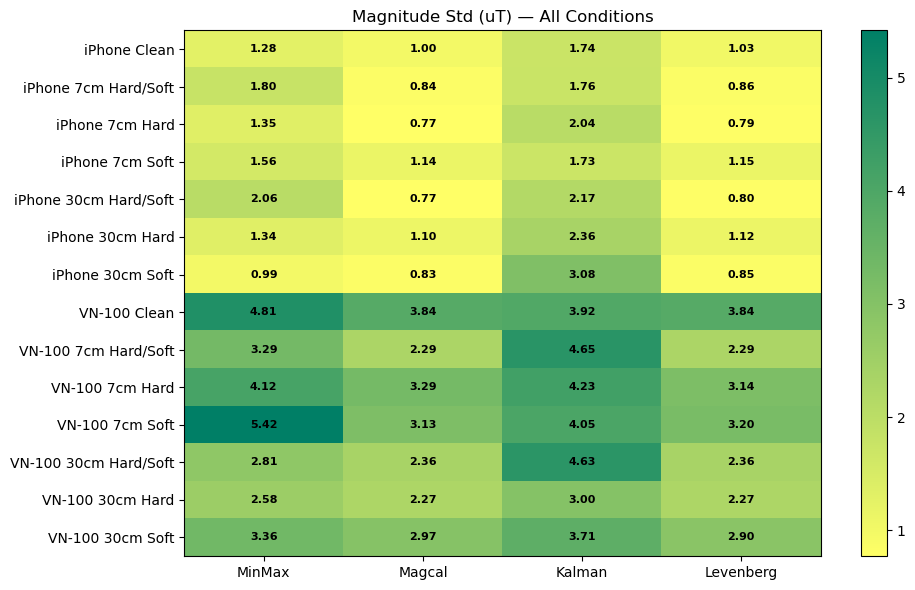

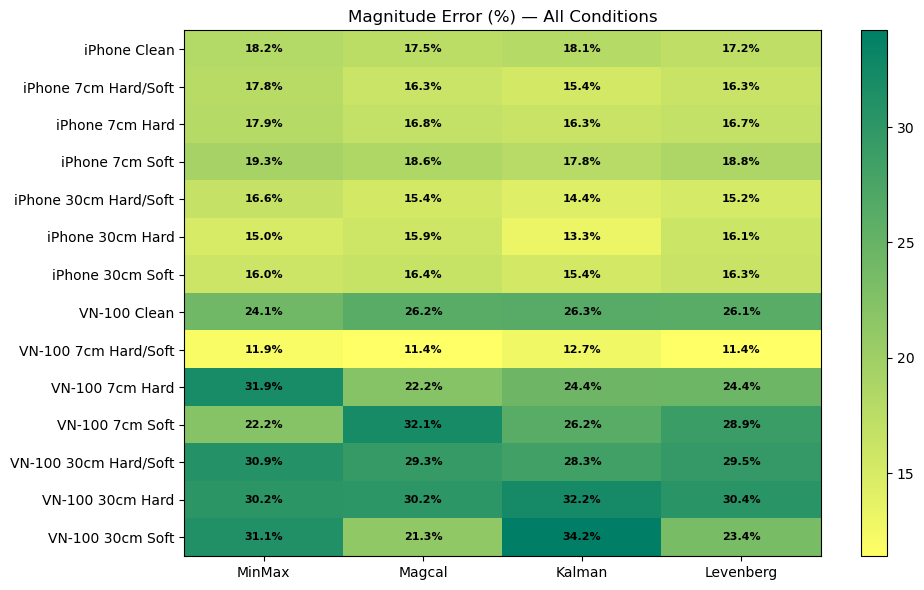

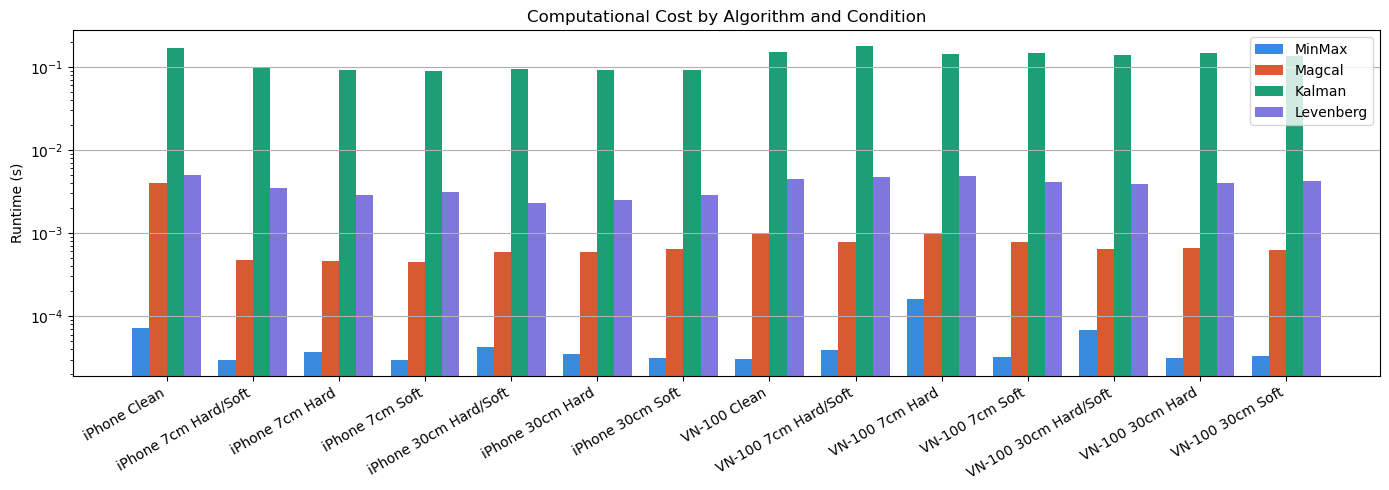

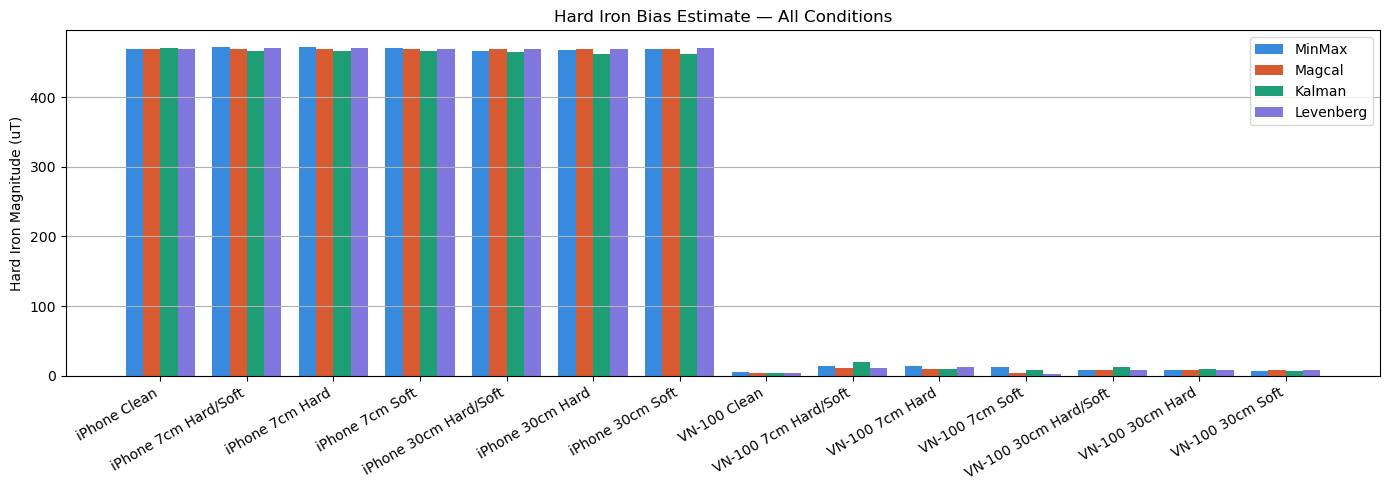

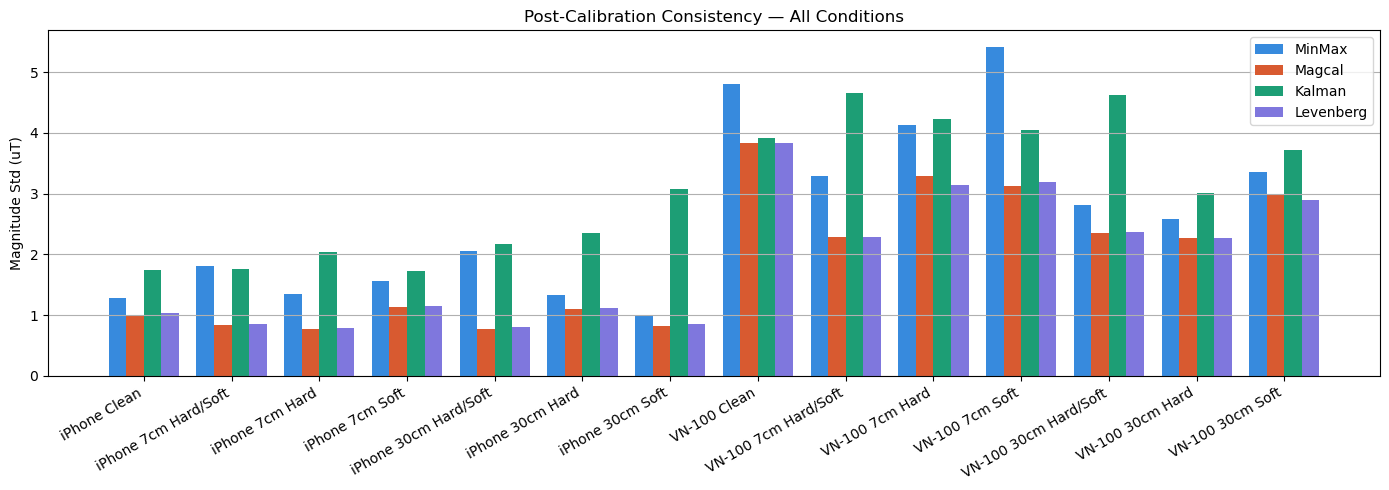

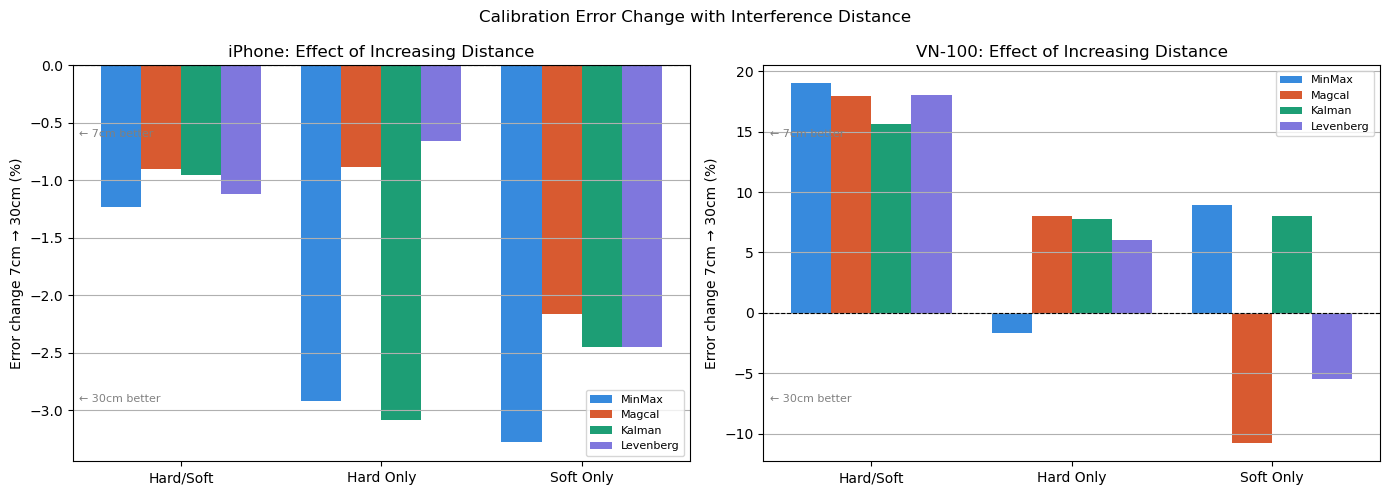

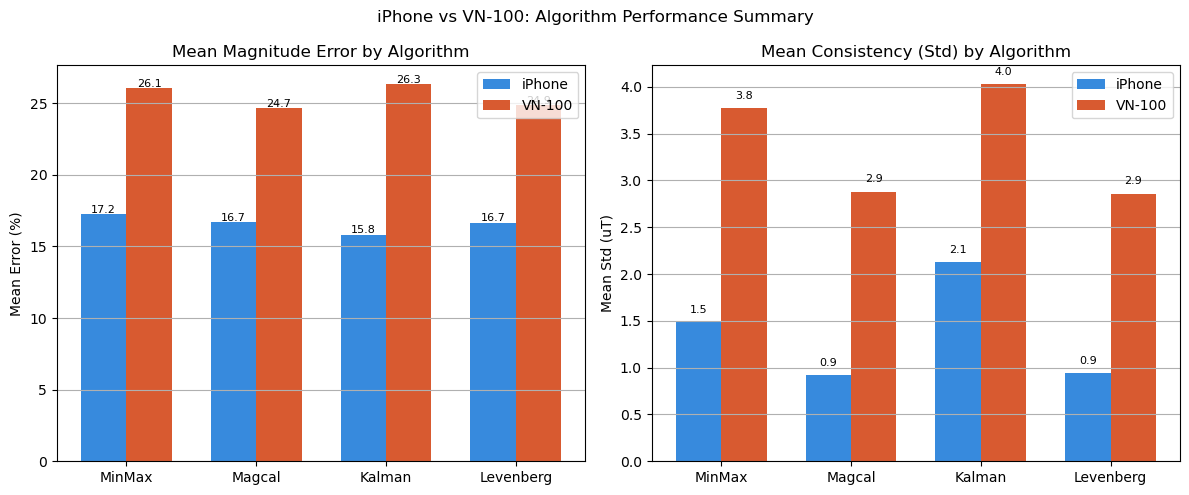

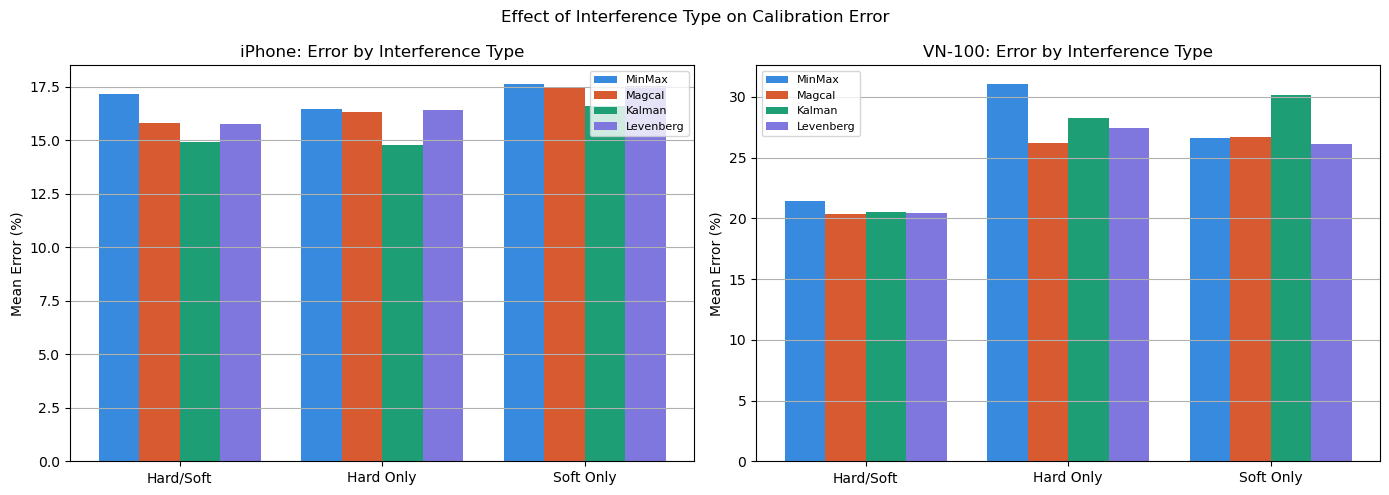

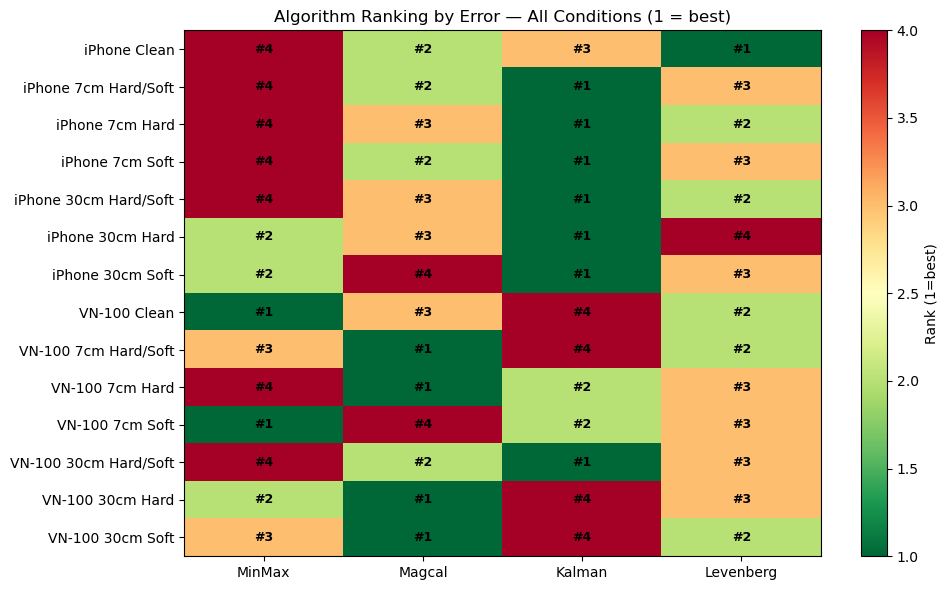

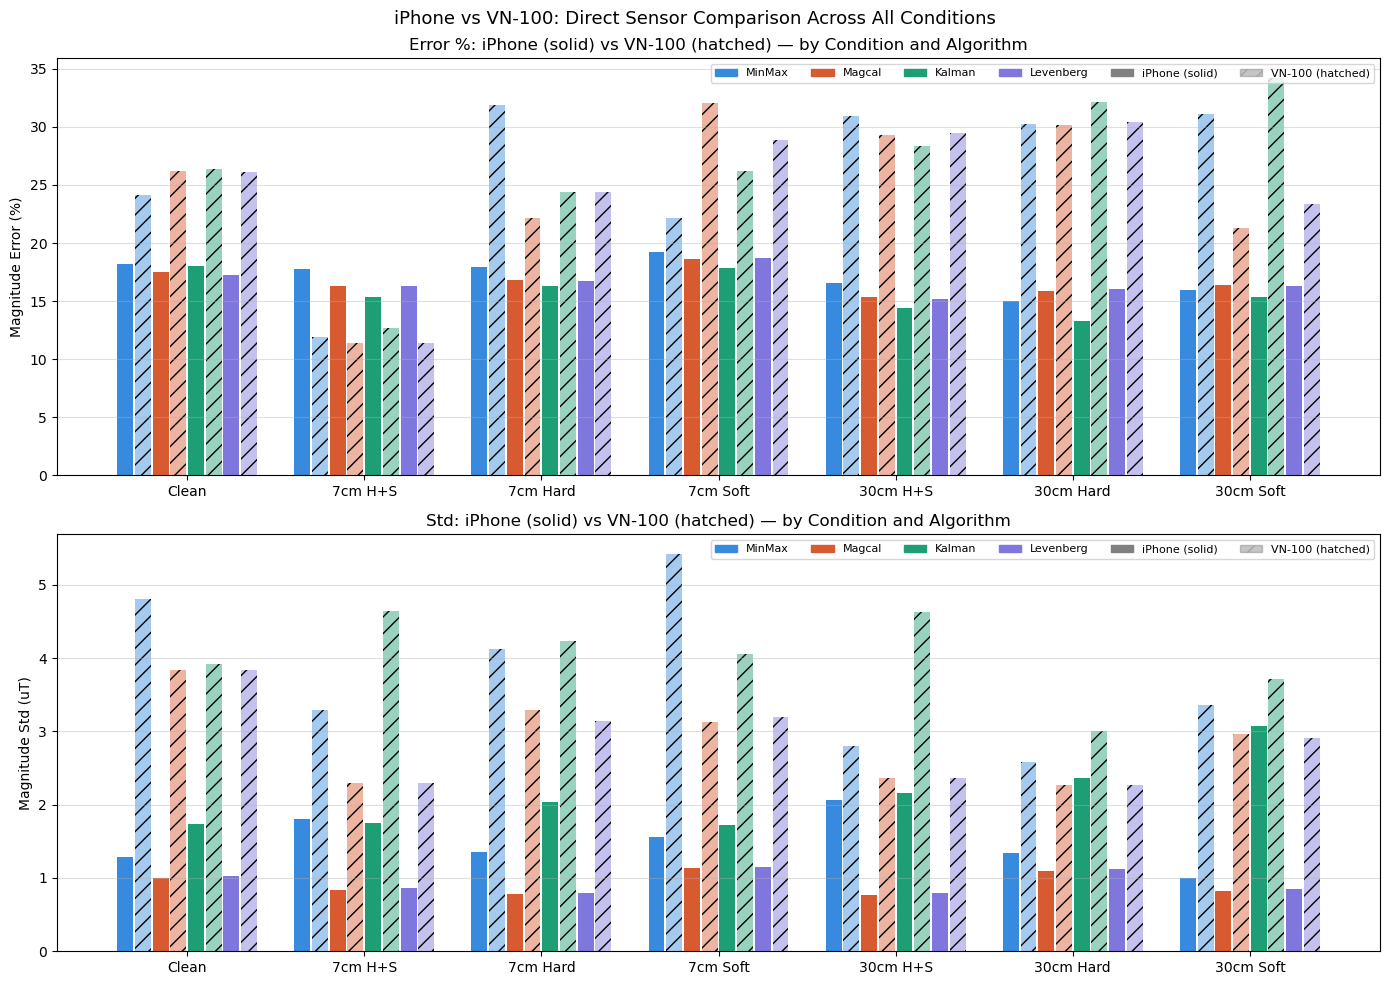

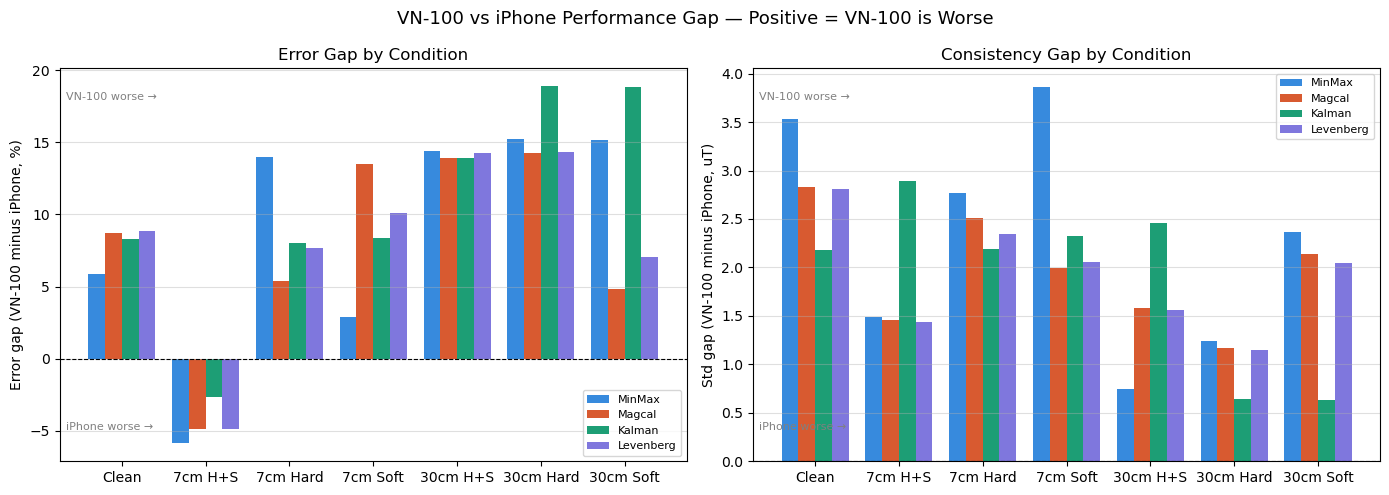


--- Algorithm Ranking Summary ---
MinMax        avg rank: 3.00  |  times ranked #1: 2/14
Magcal        avg rank: 2.29  |  times ranked #1: 4/14
Kalman        avg rank: 2.14  |  times ranked #1: 7/14
Levenberg     avg rank: 2.57  |  times ranked #1: 1/14


In [44]:
def plot_summary(all_metrics, all_labels, algorithms):
    n_ds  = len(all_labels)
    n_alg = len(algorithms)
    x = np.arange(n_ds)
    width = 0.8 / n_alg
    offsets = np.arange(n_alg) * width - (n_alg - 1) * width / 2

    std_mat     = np.array([[all_metrics[i][j]['stdMag']      for j in range(n_alg)] for i in range(n_ds)])
    error_mat   = np.array([[all_metrics[i][j]['errorPct']    for j in range(n_alg)] for i in range(n_ds)])
    runtime_mat = np.array([[all_metrics[i][j]['runtime']     for j in range(n_alg)] for i in range(n_ds)])
    hi_mat      = np.array([[all_metrics[i][j]['hardIronMag'] for j in range(n_alg)] for i in range(n_ds)])

    cmap   = plt.cm.summer_r
    colors = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD', '#BA7517']

    # --- Heatmap: Magnitude Std ---
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(std_mat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(n_alg)); ax.set_xticklabels(algorithms)
    ax.set_yticks(range(n_ds));  ax.set_yticklabels(all_labels)
    ax.set_title('Magnitude Std (uT) — All Conditions')
    for r in range(n_ds):
        for c in range(n_alg):
            ax.text(c, r, f'{std_mat[r, c]:.2f}', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.show()

    # --- Heatmap: Magnitude Error % ---
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(error_mat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(n_alg)); ax.set_xticklabels(algorithms)
    ax.set_yticks(range(n_ds));  ax.set_yticklabels(all_labels)
    ax.set_title('Magnitude Error (%) — All Conditions')
    for r in range(n_ds):
        for c in range(n_alg):
            ax.text(c, r, f'{error_mat[r, c]:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.show()

    # --- Bar: Runtime (log scale) ---
    fig, ax = plt.subplots(figsize=(14, 5))
    for j, (alg, col) in enumerate(zip(algorithms, colors)):
        ax.bar(x + offsets[j], runtime_mat[:, j], width, label=alg, color=col)
    ax.set_xticks(x); ax.set_xticklabels(all_labels, rotation=30, ha='right')
    ax.set_ylabel('Runtime (s)')
    ax.set_yscale('log')
    ax.set_title('Computational Cost by Algorithm and Condition')
    ax.legend(); ax.grid(axis='y')
    plt.tight_layout(); plt.show()

    # --- Bar: Hard Iron Magnitude ---
    fig, ax = plt.subplots(figsize=(14, 5))
    for j, (alg, col) in enumerate(zip(algorithms, colors)):
        ax.bar(x + offsets[j], hi_mat[:, j], width, label=alg, color=col)
    ax.set_xticks(x); ax.set_xticklabels(all_labels, rotation=30, ha='right')
    ax.set_ylabel('Hard Iron Magnitude (uT)')
    ax.set_title('Hard Iron Bias Estimate — All Conditions')
    ax.legend(); ax.grid(axis='y')
    plt.tight_layout(); plt.show()

    # --- Bar: Std Comparison ---
    fig, ax = plt.subplots(figsize=(14, 5))
    for j, (alg, col) in enumerate(zip(algorithms, colors)):
        ax.bar(x + offsets[j], std_mat[:, j], width, label=alg, color=col)
    ax.set_xticks(x); ax.set_xticklabels(all_labels, rotation=30, ha='right')
    ax.set_ylabel('Magnitude Std (uT)')
    ax.set_title('Post-Calibration Consistency — All Conditions')
    ax.legend(); ax.grid(axis='y')
    plt.tight_layout(); plt.show()

    # ================================================================
    # NEW PLOT 1: Distance effect — 7cm vs 30cm error by algorithm
    # Shows whether moving interference further away helps calibration
    # ================================================================
    # Dataset index layout:
    # iPhone: 0=Clean, 1=7cmHS, 2=7cmHard, 3=7cmSoft, 4=30cmHS, 5=30cmHard, 6=30cmSoft
    # VN100:  7=Clean, 8=7cmHS, 9=7cmHard, 10=7cmSoft, 11=30cmHS, 12=30cmHard, 13=30cmSoft
    dist_labels  = ['Hard/Soft', 'Hard Only', 'Soft Only']
    iphone_7cm   = [1, 2, 3]   # dataset indices
    iphone_30cm  = [4, 5, 6]
    vn_7cm       = [8, 9, 10]
    vn_30cm      = [11, 12, 13]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    for ax, sensor, idx_7, idx_30 in zip(
        axes,
        ['iPhone', 'VN-100'],
        [iphone_7cm, vn_7cm],
        [iphone_30cm, vn_30cm]
    ):
        x2 = np.arange(len(dist_labels))
        w2 = 0.8 / n_alg
        off2 = np.arange(n_alg) * w2 - (n_alg - 1) * w2 / 2
        for j, (alg, col) in enumerate(zip(algorithms, colors)):
            err_7  = [error_mat[i, j] for i in idx_7]
            err_30 = [error_mat[i, j] for i in idx_30]
            delta  = [e30 - e7 for e7, e30 in zip(err_7, err_30)]
            ax.bar(x2 + off2[j], delta, w2, label=alg, color=col)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(x2); ax.set_xticklabels(dist_labels)
        ax.set_ylabel('Error change 7cm → 30cm (%)')
        ax.set_title(f'{sensor}: Effect of Increasing Distance')
        ax.legend(fontsize=8); ax.grid(axis='y')
        # Negative = 30cm is better, positive = 30cm is worse
        ax.annotate('← 30cm better', xy=(0.01, 0.15), xycoords='axes fraction',
                    fontsize=8, color='gray')
        ax.annotate('← 7cm better', xy=(0.01, 0.82), xycoords='axes fraction',
                    fontsize=8, color='gray')
    plt.suptitle('Calibration Error Change with Interference Distance', fontweight='500')
    plt.tight_layout(); plt.show()

    # ================================================================
    # NEW PLOT 2: iPhone vs VN-100 mean error per algorithm
    # Direct sensor comparison averaged across all interference conditions
    # ================================================================
    iphone_idx = [0, 1, 2, 3, 4, 5, 6]
    vn_idx     = [7, 8, 9, 10, 11, 12, 13]

    iphone_mean_err = [np.mean([error_mat[i, j] for i in iphone_idx]) for j in range(n_alg)]
    vn_mean_err     = [np.mean([error_mat[i, j] for i in vn_idx])     for j in range(n_alg)]
    iphone_mean_std = [np.mean([std_mat[i, j]   for i in iphone_idx]) for j in range(n_alg)]
    vn_mean_std     = [np.mean([std_mat[i, j]   for i in vn_idx])     for j in range(n_alg)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x3 = np.arange(n_alg)
    w3 = 0.35
    for ax, iphone_vals, vn_vals, ylabel, title in zip(
        axes,
        [iphone_mean_err, iphone_mean_std],
        [vn_mean_err,     vn_mean_std],
        ['Mean Error (%)', 'Mean Std (uT)'],
        ['Mean Magnitude Error by Algorithm', 'Mean Consistency (Std) by Algorithm']
    ):
        ax.bar(x3 - w3/2, iphone_vals, w3, label='iPhone',  color='#378ADD')
        ax.bar(x3 + w3/2, vn_vals,     w3, label='VN-100',  color='#D85A30')
        ax.set_xticks(x3); ax.set_xticklabels(algorithms)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(); ax.grid(axis='y')
        for k, (iv, vv) in enumerate(zip(iphone_vals, vn_vals)):
            ax.text(k - w3/2, iv + 0.1, f'{iv:.1f}', ha='center', fontsize=8)
            ax.text(k + w3/2, vv + 0.1, f'{vv:.1f}', ha='center', fontsize=8)
    plt.suptitle('iPhone vs VN-100: Algorithm Performance Summary', fontweight='500')
    plt.tight_layout(); plt.show()

    # ================================================================
    # NEW PLOT 3: Interference type comparison (Hard vs Soft vs Combined)
    # Shows which type of interference is hardest to calibrate against
    # ================================================================
    type_labels = ['Hard/Soft', 'Hard Only', 'Soft Only']
    iphone_types = [[1, 4], [2, 5], [3, 6]]   # [7cm_idx, 30cm_idx] per type
    vn_types     = [[8, 11], [9, 12], [10, 13]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, sensor, type_indices in zip(axes, ['iPhone', 'VN-100'], [iphone_types, vn_types]):
        x4 = np.arange(len(type_labels))
        w4 = 0.8 / n_alg
        off4 = np.arange(n_alg) * w4 - (n_alg - 1) * w4 / 2
        for j, (alg, col) in enumerate(zip(algorithms, colors)):
            # Average error across 7cm and 30cm for each interference type
            mean_errs = [np.mean([error_mat[i, j] for i in idxs]) for idxs in type_indices]
            ax.bar(x4 + off4[j], mean_errs, w4, label=alg, color=col)
        ax.set_xticks(x4); ax.set_xticklabels(type_labels)
        ax.set_ylabel('Mean Error (%)')
        ax.set_title(f'{sensor}: Error by Interference Type')
        ax.legend(fontsize=8); ax.grid(axis='y')
    plt.suptitle('Effect of Interference Type on Calibration Error', fontweight='500')
    plt.tight_layout(); plt.show()

    # ================================================================
    # NEW PLOT 4: Algorithm ranking heatmap
    # For each dataset, rank algorithms 1 (best) to N (worst) by error
    # ================================================================
    rank_mat = np.argsort(np.argsort(error_mat, axis=1), axis=1) + 1  # 1=best

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(rank_mat, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=n_alg)
    plt.colorbar(im, ax=ax, label='Rank (1=best)')
    ax.set_xticks(range(n_alg)); ax.set_xticklabels(algorithms)
    ax.set_yticks(range(n_ds));  ax.set_yticklabels(all_labels)
    ax.set_title('Algorithm Ranking by Error — All Conditions (1 = best)')
    for r in range(n_ds):
        for c in range(n_alg):
            ax.text(c, r, f'#{rank_mat[r, c]}', ha='center', va='center',
                    fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ================================================================
    # NEW PLOT 5: Sensor comparison — iPhone vs VN-100 side by side
    # for every interference condition, showing the performance gap
    # ================================================================

    # Paired conditions: iPhone index vs VN-100 index
    # Clean, 7cmHS, 7cmHard, 7cmSoft, 30cmHS, 30cmHard, 30cmSoft
    condition_labels = ['Clean', '7cm H+S', '7cm Hard', '7cm Soft',
                        '30cm H+S', '30cm Hard', '30cm Soft']
    iphone_indices = [0, 1, 2, 3, 4, 5, 6]
    vn_indices     = [7, 8, 9, 10, 11, 12, 13]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- Top: Error % comparison per condition ---
    ax = axes[0]
    x5 = np.arange(len(condition_labels))
    w5 = 0.8 / n_alg
    off5 = np.arange(n_alg) * w5 - (n_alg - 1) * w5 / 2

    for j, (alg, col) in enumerate(zip(algorithms, colors)):
        iphone_errs = [error_mat[i, j] for i in iphone_indices]
        vn_errs     = [error_mat[i, j] for i in vn_indices]
        # Plot iPhone as solid, VN-100 as hatched
        bars_i = ax.bar(x5 + off5[j] - w5*0.25, iphone_errs, w5*0.45,
                        color=col, label=f'{alg} iPhone')
        bars_v = ax.bar(x5 + off5[j] + w5*0.25, vn_errs,     w5*0.45,
                        color=col, alpha=0.45, hatch='//', label=f'{alg} VN-100')

    ax.set_xticks(x5); ax.set_xticklabels(condition_labels)
    ax.set_ylabel('Magnitude Error (%)')
    ax.set_title('Error %: iPhone (solid) vs VN-100 (hatched) — by Condition and Algorithm')
    ax.grid(axis='y', alpha=0.4)

    # Custom legend showing just algorithm colors + sensor style
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    alg_patches  = [Patch(color=colors[j], label=algorithms[j]) for j in range(n_alg)]
    style_patches = [Patch(color='gray', label='iPhone (solid)'),
                     Patch(color='gray', alpha=0.45, hatch='//', label='VN-100 (hatched)')]
    ax.legend(handles=alg_patches + style_patches, fontsize=8,
              ncol=n_alg + 2, loc='upper right')

    # --- Bottom: Std comparison per condition ---
    ax = axes[1]
    for j, (alg, col) in enumerate(zip(algorithms, colors)):
        iphone_stds = [std_mat[i, j] for i in iphone_indices]
        vn_stds     = [std_mat[i, j] for i in vn_indices]
        ax.bar(x5 + off5[j] - w5*0.25, iphone_stds, w5*0.45,
               color=col)
        ax.bar(x5 + off5[j] + w5*0.25, vn_stds,     w5*0.45,
               color=col, alpha=0.45, hatch='//')

    ax.set_xticks(x5); ax.set_xticklabels(condition_labels)
    ax.set_ylabel('Magnitude Std (uT)')
    ax.set_title('Std: iPhone (solid) vs VN-100 (hatched) — by Condition and Algorithm')
    ax.grid(axis='y', alpha=0.4)
    ax.legend(handles=alg_patches + style_patches, fontsize=8,
              ncol=n_alg + 2, loc='upper right')

    plt.suptitle('iPhone vs VN-100: Direct Sensor Comparison Across All Conditions',
                 fontsize=13, fontweight='500')
    plt.tight_layout(); plt.show()

    # --- Bonus: gap plot — how much worse is VN-100 than iPhone per condition ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mat, ylabel, title in zip(
        axes,
        [error_mat, std_mat],
        ['Error gap (VN-100 minus iPhone, %)', 'Std gap (VN-100 minus iPhone, uT)'],
        ['Error Gap by Condition', 'Consistency Gap by Condition']
    ):
        for j, (alg, col) in enumerate(zip(algorithms, colors)):
            gaps = [mat[vn_indices[k], j] - mat[iphone_indices[k], j]
                    for k in range(len(condition_labels))]
            ax.bar(x5 + off5[j], gaps, w5, color=col, label=alg)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(x5); ax.set_xticklabels(condition_labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)
        ax.annotate('VN-100 worse →', xy=(0.01, 0.92), xycoords='axes fraction',
                    fontsize=8, color='gray')
        ax.annotate('iPhone worse →', xy=(0.01, 0.08), xycoords='axes fraction',
                    fontsize=8, color='gray')

    plt.suptitle('VN-100 vs iPhone Performance Gap — Positive = VN-100 is Worse',
                 fontsize=13, fontweight='500')
    plt.tight_layout(); plt.show()

    # Print rank summary
    print('\n--- Algorithm Ranking Summary ---')
    avg_ranks = rank_mat.mean(axis=0)
    for j, alg in enumerate(algorithms):
        wins = np.sum(rank_mat[:, j] == 1)
        print(f'{alg:12s}  avg rank: {avg_ranks[j]:.2f}  |  times ranked #1: {wins}/{n_ds}')

    


all_labels = [ds[2] for ds in DATASETS]
plot_summary(all_metrics, all_labels, ALGORITHMS)

Loaded: data/SLACleanMagnetometerUncalibrated.csv | Sensor: iphone | Samples: 4029 | Rate: 24.9 Hz


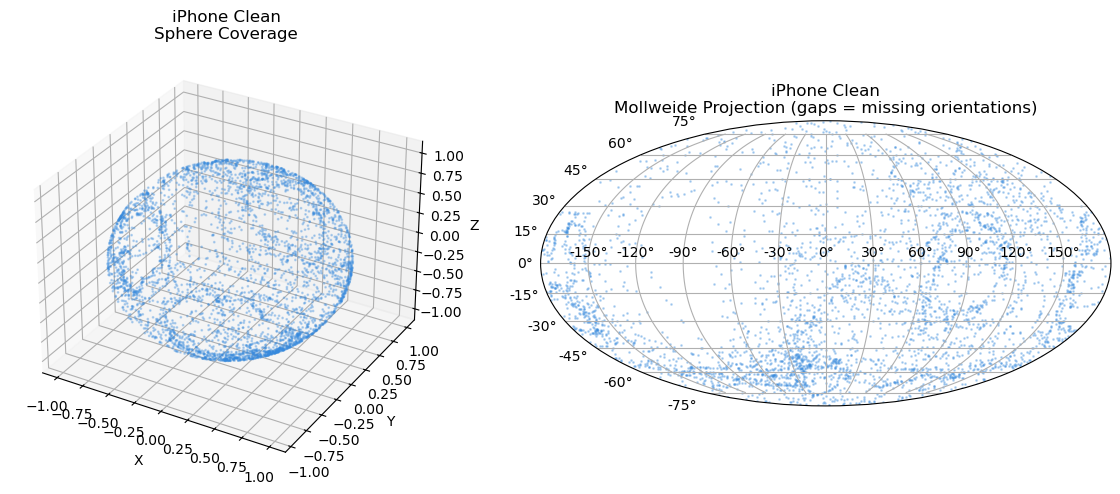

iPhone Clean: sphere coverage = 95.0% of bins occupied
Loaded: data/vn30HS.csv | Sensor: vn100 | Samples: 5696 | Rate: 39916658328.7 Hz


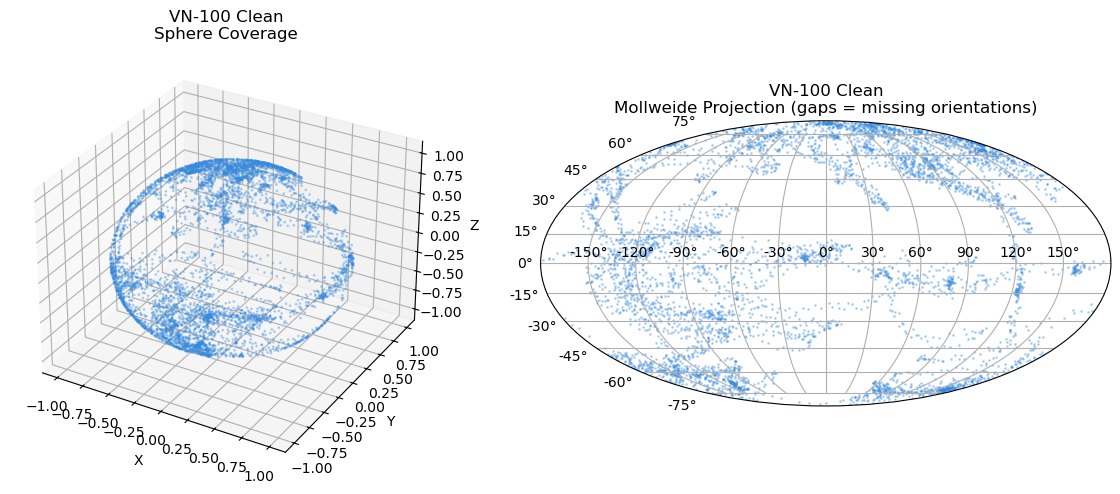

VN-100 Clean: sphere coverage = 78.9% of bins occupied


In [48]:
def plot_sphere_coverage(mag_x, mag_y, mag_z, label, expected_field=52.0):
    """
    Plot the distribution of magnetometer readings on a unit sphere
    to visualize orientation coverage quality.
    """
    from mpl_toolkits.mplot3d import Axes3D

    # Center the data by removing hard iron (rough estimate)
    cx = (mag_x.max() + mag_x.min()) / 2
    cy = (mag_y.max() + mag_y.min()) / 2
    cz = (mag_z.max() + mag_z.min()) / 2
    x = mag_x - cx
    y = mag_y - cy
    z = mag_z - cz

    # Normalize to unit sphere
    norms = np.sqrt(x**2 + y**2 + z**2)
    x_n = x / norms
    y_n = y / norms
    z_n = z / norms

    fig = plt.figure(figsize=(12, 5))

    # 3D scatter on sphere
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x_n, y_n, z_n, s=1, alpha=0.3, c='#378ADD')
    ax1.set_title(f'{label}\nSphere Coverage')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

    # 2D Mollweide projection (like a world map) — better for seeing gaps
    ax2 = fig.add_subplot(122, projection='mollweide')
    # Convert to lat/lon
    lat = np.arcsin(np.clip(z_n, -1, 1))
    lon = np.arctan2(y_n, x_n)
    ax2.scatter(lon, lat, s=1, alpha=0.3, c='#378ADD')
    ax2.set_title(f'{label}\nMollweide Projection (gaps = missing orientations)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Coverage score: divide sphere into bins and count how many are occupied
    n_bins = 20
    lat_bins = np.linspace(-np.pi/2, np.pi/2, n_bins)
    lon_bins = np.linspace(-np.pi, np.pi, n_bins)
    lat_vals = np.arcsin(np.clip(z_n, -1, 1))
    lon_vals = np.arctan2(y_n, x_n)
    H, _, _ = np.histogram2d(lat_vals, lon_vals, bins=[lat_bins, lon_bins])
    occupied = np.sum(H > 0)
    total = (n_bins-1)**2
    coverage_pct = 100 * occupied / total
    print(f'{label}: sphere coverage = {coverage_pct:.1f}% of bins occupied')
    return coverage_pct

# Check coverage for clean datasets
mag_x, mag_y, mag_z, _ = load_sensor_data(
    'data/SLACleanMagnetometerUncalibrated.csv', 'iphone')
iphone_cov = plot_sphere_coverage(mag_x, mag_y, mag_z, 'iPhone Clean')

mag_x, mag_y, mag_z, _ = load_sensor_data(
    'data/vn30HS.csv', 'vn100')
vn_cov = plot_sphere_coverage(mag_x, mag_y, mag_z, 'VN-100 Clean')



Loaded: data/vn7Soft.csv | Sensor: vn100 | Samples: 5958 | Rate: 39992579155.7 Hz


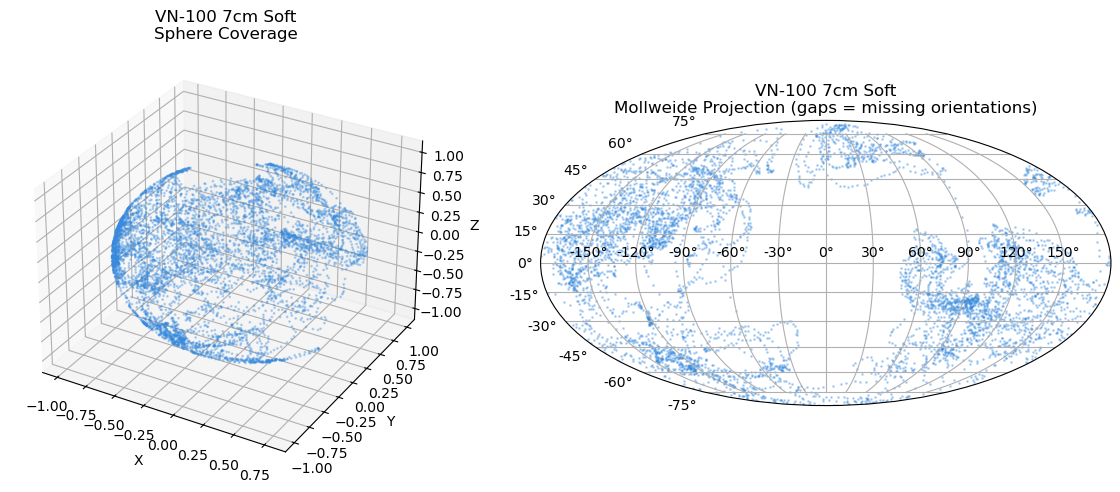

VN-100 7cm Soft: sphere coverage = 77.0% of bins occupied


77.00831024930748